# Setting

## Import packages

In [2]:
# === System & Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
from dotenv import load_dotenv
import requests

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### check_table_info

In [3]:
def check_table_info(target_df):
    """
    To check the unique values, dtype, example, missing rate of each column
    """
    table_info = []
    for col in target_df:
        table_info_row = []
        table_info_row.append(col)
        table_info_row.append(target_df[col].nunique())
        table_info_row.append(target_df[col].dtype)
        table_info_row.append(target_df[col].iloc[0])
        table_info_row.append(round(target_df[col].isna().sum() / target_df.shape[0]*100,2))

        table_info.append(table_info_row)
    res = pd.DataFrame(table_info, columns=['col_name', 'unique_values', 'dtype', 'example', 'missing%'])

    return res

### load_geoDataFrame

In [4]:
def load_geoDataFrame(filepath):
    """
    Load a GeoDataFrame from a CSV file with a geometry column in WKT format.

    Parameters:
        filepath (str): Path to the CSV file containing the saved GeoDataFrame.

    Returns:
        GeoDataFrame: A GeoDataFrame reconstructed from the CSV, with geometries parsed from WKT strings.
    
    Notes:
        - Assumes the geometry column is named 'geometry' and stored in WKT format.
        - The returned GeoDataFrame is assigned the CRS 'EPSG:4326' by default.
    """
    df = pd.read_csv(filepath)
    df['geometry'] = df['geometry'].apply(loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

### gen_point_area_buffer_mapping

In [5]:
def gen_point_area_buffer_mapping(point_df, lat_col, lon_col, grid_df, grid_id_col='grid_id', buffer_radius_m=1000):
    """
    Maps each point in point_df to a nearby grid cell (from grid_df) using a centroid-based buffer.

    Parameters:
        point_df (pd.DataFrame): DataFrame with point locations, must include latitude and longitude columns.
        lat_col (str): Name of the latitude column in point_df.
        lon_col (str): Name of the longitude column in point_df.
        grid_df (gpd.GeoDataFrame): GeoDataFrame with polygon grid geometries (e.g., Manhattan grid).
        grid_id_col (str): Column in grid_df representing the unique ID of each grid (default: 'grid_id').
        buffer_radius_m (float): Radius in meters to buffer around each grid's centroid (default: 1000 meters).

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with all points that fall within any grid centroid's buffer,
                          including matched grid IDs.
    """
    # Project grid to a suitable projected CRS (NYC local)
    grid_proj = grid_df.to_crs(epsg=2263)
    grid_proj['centroid'] = grid_proj.geometry.centroid
    grid_proj['buffer'] = grid_proj['centroid'].buffer(buffer_radius_m)

    # Create buffer GeoDataFrame
    buffer_gdf = grid_proj[[grid_id_col, 'buffer']].copy()
    buffer_gdf = buffer_gdf.set_geometry('buffer')
    buffer_gdf = buffer_gdf.set_crs(epsg=2263)

    # Prepare point GeoDataFrame and project to same CRS
    point_df = point_df.dropna(subset=[lat_col, lon_col]).copy()
    point_gdf = gpd.GeoDataFrame(
        point_df,
        geometry=gpd.points_from_xy(point_df[lon_col], point_df[lat_col]),
        crs="EPSG:4326"
    )
    point_proj = point_gdf.to_crs(epsg=2263)

    # Drop potential naming conflict column
    if 'index_right' in point_proj.columns:
        point_proj = point_proj.drop(columns=['index_right'])

    # Spatial join: points within buffer zones
    joined = gpd.sjoin(point_proj, buffer_gdf, how='inner', predicate='within')

    return joined

### calculate_trips_by_buffer

In [6]:
def calculate_trips_by_buffer(
    df, 
    grid_df, 
    prefix,
    lat_col='lat', 
    lon_col='lon', 
    trip_time_col='trip_time', 
    trips_col='trips', 
    grid_id_col='grid_id', 
    buffer_distances=[500, 900, 1200], 
    buffer_labels=['core', 'secondary', 'edge']
):
    """
    General function to calculate trips (bike, subway, etc.) within multiple buffer zones around grids.

    Parameters:
        df (pd.DataFrame): DataFrame containing trip data.
        grid_df (pd.DataFrame): DataFrame containing grid geometry and grid IDs.
        lat_col (str): Latitude column name.
        lon_col (str): Longitude column name.
        trip_time_col (str): Trip time column name.
        trips_col (str): Trips column name.
        grid_id_col (str): Grid ID column name.
        prefix (str): The prefix for output column names (e.g., 'bike', 'subway').
        buffer_distances (list): List of buffer distances in meters.
        buffer_labels (list): Corresponding labels for buffer zones (same order as distances).
        point_area_func (function): Function to calculate buffer mapping (your existing spatial function).

    Returns:
        pd.DataFrame: Merged DataFrame with trips per zone and time.
    """
    assert len(buffer_distances) == len(buffer_labels), "buffer_distances and buffer_labels must be the same length."
    
    prefix = prefix.strip().lower()
    station_points = df[[lat_col, lon_col]].drop_duplicates()

    buffer_dfs = {}
    for dist, label in zip(buffer_distances, buffer_labels):
        buffer_df = gen_point_area_buffer_mapping(
            point_df=station_points,
            lat_col=lat_col,
            lon_col=lon_col,
            grid_df=grid_df[[grid_id_col, 'geometry']],
            grid_id_col=grid_id_col,
            buffer_radius_m=dist
        )
        buffer_dfs[label] = buffer_df

    # Group trips for each zone
    merged = None
    for label in buffer_labels:
        buffer_df = buffer_dfs[label]
        tmp = df.merge(buffer_df[[lat_col, lon_col, grid_id_col]], on=[lat_col, lon_col])
        tmp_grouped = tmp.groupby([trip_time_col, grid_id_col])[trips_col].sum().reset_index()
        tmp_grouped = tmp_grouped.rename(columns={trips_col: f'{prefix}_trips_{label}_zone_cumulative'})
        
        if merged is None:
            merged = tmp_grouped
        else:
            merged = merged.merge(tmp_grouped, on=[trip_time_col, grid_id_col], how='outer').fillna(0)
    
    # Extract date and hour
    merged['date'] = pd.to_datetime(pd.to_datetime(merged[trip_time_col]).dt.date)
    merged['hour'] = pd.to_datetime(merged[trip_time_col]).dt.hour.astype(int)
    
    # Calculate exclusive trips within each zone (non-overlapping rings)
    cumulative_cols = [f'{prefix}_trips_{label}_zone_cumulative' for label in buffer_labels]
    merged[f'{prefix}_trips_{buffer_labels[-1]}_zone'] = merged[cumulative_cols[-1]] - merged[cumulative_cols[-2]]
    merged[f'{prefix}_trips_{buffer_labels[1]}_zone'] = merged[cumulative_cols[1]] - merged[cumulative_cols[0]]
    merged[f'{prefix}_trips_{buffer_labels[0]}_zone'] = merged[cumulative_cols[0]]
    
    # Final column selection
    final_cols = ['date', 'hour', grid_id_col] + \
                 [f'{prefix}_trips_{label}_zone' for label in buffer_labels]
    
    return merged[final_cols]

### convert_percentile_to_level

In [7]:
def convert_percentile_to_level(series):
    """
    Convert continuous percentile values to 5-level categorical bins
    (equal-width binning from min to max).
    """
    min_val = series.min()
    max_val = series.max()
    bins = np.linspace(min_val, max_val, 6)  # 5 bins
    labels = ['1', '2', '3', '4', '5']

    result = pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return result

### plot_busyness_percentile_map

In [8]:
def plot_busyness_percentile_map(df, date_str, hour_int, busyness_level, ax=None, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter data for the specified date and hour
    df_hour = df[(df['date'] == date_str) & (df['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # 3. Drop rows with missing percentile values
    gdf = gdf.dropna(subset=[busyness_level])

    # 4. Prepare ax
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 5. Plot the heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'title': busyness_level, 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")


### classification_evaluation

In [9]:
def classification_evaluation(y_actual, y_pred):
    """
    Prints a full evaluation report for multiclass classification results.

    Shows:
    - Accuracy
    - Precision (macro)
    - Recall (macro)
    - F1 score (macro)
    - Confusion matrix
    - Classification report

    Args:
        y_actual (array-like): True class labels
        y_pred (array-like): Predicted class labels
    """

    print("Accuracy       :", round(accuracy_score(y_actual, y_pred), 3))
    print("Precision Score:", round(precision_score(y_actual, y_pred, average='macro'), 3))
    print("Recall Score   :", round(recall_score(y_actual, y_pred, average='macro'), 3))
    print("F1 Score       :", round(f1_score(y_actual, y_pred, average='macro'), 3))
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred, zero_division=1))

### predict_sample_dataset

In [10]:
def predict_sample_dataset(model, input_X, input_y, 
                           sample_size=1000000, 
                           y_type='categorical', 
                           is_lgbm=False, is_cat=False,
                           eval_metric=None):
    """
    Train and evaluate a model on a sampled dataset.

    Parameters:
        model: sklearn, LightGBM, or CatBoost model
        input_X (DataFrame): feature set
        input_y (Series): target
        sample_size (int): max sample size
        y_type (str): 'continuous' or 'categorical'
        is_lgbm (bool): use LGBM-style training
        is_cat (bool): use CatBoost-style training
        eval_metric (str): metric for model evaluation
    """

    if y_type not in ['continuous', 'categorical']:
        raise ValueError('y_type must be "continuous" or "categorical"')

    # Sample
    X_sample = input_X.sample(n=min(sample_size, len(input_X)), random_state=42)
    y_sample = input_y.loc[X_sample.index]

    # Split
    stratify_arg = y_sample if y_type == 'categorical' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, stratify=stratify_arg, random_state=42
    )

    cat_features = X_sample.select_dtypes('category').columns.tolist()

    # Fit
    if not is_lgbm and not is_cat:
        model.fit(X_train, y_train)
    elif is_lgbm:
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=eval_metric,
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(10)]
        )
    elif is_cat:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            cat_features=cat_features)

    # Predict
    y_pred = model.predict(X_test)

    # Optional fix for CatBoost regression/classification float output
    if is_cat and y_type == 'categorical' and not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.round(y_pred).astype(int)

    # Evaluate
    if y_type == 'continuous':
        y_test_label = convert_percentile_to_level(pd.Series(y_test).reset_index(drop=True))
        y_pred_label = convert_percentile_to_level(pd.Series(y_pred).reset_index(drop=True))
    else:
        y_test_label = y_test
        y_pred_label = y_pred

    classification_evaluation(y_test_label, y_pred_label)

### encode_features

In [11]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def encode_features(input_df, input_features, drop_first=True):
    """
    Transforms input features for modeling:
    
    - Boolean features are converted to integers (0 or 1).
    - Categorical features (dtype 'category') are one-hot encoded.
        - Optionally drops the first dummy column to avoid multicollinearity.
    - Numerical (continuous) features are standardized using StandardScaler.
    
    Tracks:
    - The original-to-transformed column mappings.
    - Which dummy columns (baseline categories) were dropped.

    Args:
        input_df (pd.DataFrame): Original input DataFrame.
        input_features (list): List of column names to transform.
        drop_first (bool): Whether to drop the first dummy variable for each categorical feature.

    Returns:
        encoded_df (pd.DataFrame): Final encoded DataFrame ready for modeling.
        drop_col_df (pd.DataFrame): Info about dropped dummy columns (if any).
        mapping_df (pd.DataFrame): Mapping from original features to encoded columns.
    """
    encoded_df = pd.DataFrame(index=input_df.index)
    drop_col_records = []
    mapping_records = []

    for feature in input_features:
        series = input_df[feature]

        if series.dtype.name == 'bool':
            # Convert boolean to integer (0/1)
            encoded_df[feature] = series.astype(int)
            mapping_records.append({'original_feature': feature, 'feature': feature})

        elif series.dtype.name == 'category':
            # One-hot encode categorical
            dummies = pd.get_dummies(series, prefix=feature, prefix_sep='_', drop_first=False)

            for dummy_col in dummies.columns:
                mapping_records.append({'original_feature': feature, 'feature': dummy_col})

            if drop_first:
                dropped_col = dummies.columns[0]
                drop_col_records.append({
                    'original_feature': feature,
                    'baseline_category': dropped_col,
                    'true_cases': dummies[dropped_col].sum()
                })
                dummies.drop(columns=[dropped_col], inplace=True)

            encoded_df = pd.concat([encoded_df, dummies], axis=1)

        else:
            # Standardize numeric feature
            scaler = StandardScaler()
            standardized = scaler.fit_transform(series.values.reshape(-1, 1))
            encoded_df[feature] = standardized.flatten()
            mapping_records.append({'original_feature': feature, 'feature': feature})

    drop_col_df = pd.DataFrame(drop_col_records)
    mapping_df = pd.DataFrame(mapping_records)

    return encoded_df, drop_col_df, mapping_df

# Load DataFrame

In [12]:
new_buffer_df = pd.read_pickle('new_combined_df.pkl')
new_buffer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9986400 entries, 0 to 9986399
Data columns (total 19 columns):
 #   Column                                 Dtype   
---  ------                                 -----   
 0   month                                  category
 1   weekofyear                             category
 2   dayofweek                              category
 3   is_weekend                             category
 4   day                                    category
 5   hour                                   category
 6   is_holiday                             category
 7   temp_c                                 float64 
 8   dew_c                                  float64 
 9   wind_speed_knot                        float64 
 10  precip_mm                              float64 
 11  grid_id                                category
 12  restaurant_count                       float64 
 13  population                             float64 
 14  lat                               

# Model Comparison on Sample Dataset
- Although we previously found that lightGBM had the best performance in `02_model_comparison_and_selection.ipynb`, we will re-evaluate the alternative models on the new dataset to ensure the same trend holds.
- After comparing 13 models, the lightGBM still demonstrates the best performance on sample data as expeceted.

## Model prediction - Classification
- Use `busyness_level_4` as target variable
- LightGBM has the best performance on sample dataset

In [15]:
X_origin = new_buffer_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                        'grid_id', 'restaurant_count', 'population', # grid info
                        'lat', 'lon', # could be removed
                        'event_count', # event
                       ]]
y_origin = new_buffer_df['busyness_level_4']

In [16]:
X_no_grid = X_origin.drop(columns=['grid_id']) # Too large to encode as dummy
X_no_grid_encoded, _, feature_mapping_log = encode_features(X_no_grid, X_no_grid.columns, drop_first=True)


y_adjusted = y_origin.copy()
y_adjusted = y_adjusted.astype(int) - 1

### 1. SGDClassifier
- Accuracy       : 0.765
- Precision Score: 0.43
- Recall Score   : 0.358
- F1 Score       : 0.339

In [34]:
sgd = SGDClassifier(
    loss='log_loss',          
    max_iter=1000,
    tol=1e-3,
    learning_rate='optimal',
    random_state=42
)

Accuracy       : 0.765
Precision Score: 0.43
Recall Score   : 0.358
F1 Score       : 0.339



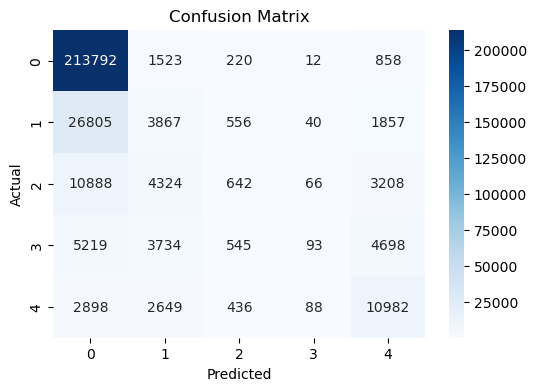


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90    216405
           1       0.24      0.12      0.16     33125
           2       0.27      0.03      0.06     19128
           3       0.31      0.01      0.01     14289
           4       0.51      0.64      0.57     17053

    accuracy                           0.76    300000
   macro avg       0.43      0.36      0.34    300000
weighted avg       0.68      0.76      0.70    300000



In [36]:
predict_sample_dataset(model=sgd, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_adjusted, 
                       sample_size=1000000)

### 2. Logistic Regression
- Accuracy       : 0.773
- Precision Score: 0.442
- Recall Score   : 0.399
- F1 Score       : 0.396

In [17]:
logreg = LogisticRegression(max_iter=3000)

Accuracy       : 0.773
Precision Score: 0.442
Recall Score   : 0.399
F1 Score       : 0.396



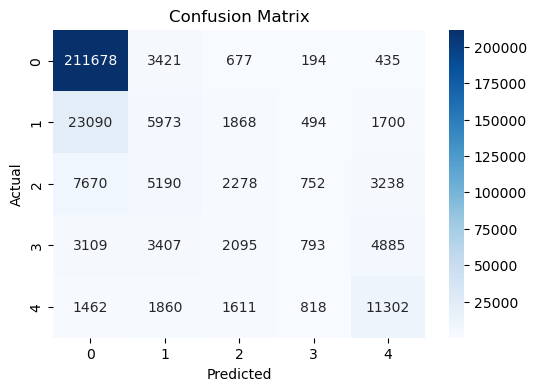


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91    216405
           1       0.30      0.18      0.23     33125
           2       0.27      0.12      0.16     19128
           3       0.26      0.06      0.09     14289
           4       0.52      0.66      0.59     17053

    accuracy                           0.77    300000
   macro avg       0.44      0.40      0.40    300000
weighted avg       0.71      0.77      0.73    300000



In [18]:
# Reuse the dataset generated for SGDClassifier
predict_sample_dataset(model=logreg, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_adjusted, 
                       sample_size=1000000)

### 3. HistGradientBoostingClassifier
- Accuracy       : 0.867
- Precision Score: 0.676
- Recall Score   : 0.65
- F1 Score       : 0.658

In [14]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,
    max_depth=6,
    random_state=42
)

Accuracy       : 0.867
Precision Score: 0.676
Recall Score   : 0.65
F1 Score       : 0.658



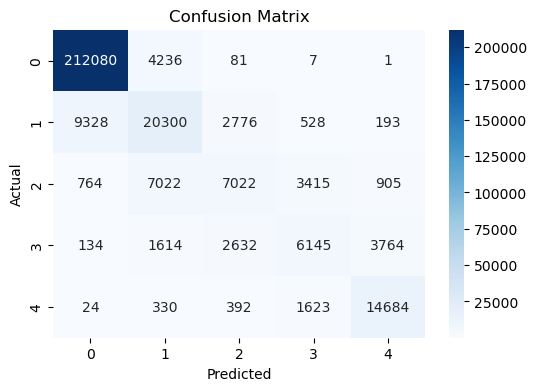


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97    216405
           1       0.61      0.61      0.61     33125
           2       0.54      0.37      0.44     19128
           3       0.52      0.43      0.47     14289
           4       0.75      0.86      0.80     17053

    accuracy                           0.87    300000
   macro avg       0.68      0.65      0.66    300000
weighted avg       0.86      0.87      0.86    300000



In [15]:
predict_sample_dataset(model=hgb, 
                       input_X=X_no_grid, 
                       input_y=y_adjusted, 
                       sample_size=1000000)

### 4. XGBoost
- Accuracy       : 0.898
- Precision Score: 0.749
- Recall Score   : 0.739
- F1 Score       : 0.743

In [16]:
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    enable_categorical=True,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

Accuracy       : 0.898
Precision Score: 0.748
Recall Score   : 0.739
F1 Score       : 0.743



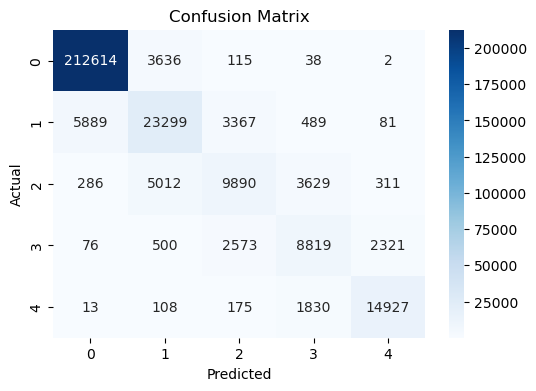


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    216405
           1       0.72      0.70      0.71     33125
           2       0.61      0.52      0.56     19128
           3       0.60      0.62      0.61     14289
           4       0.85      0.88      0.86     17053

    accuracy                           0.90    300000
   macro avg       0.75      0.74      0.74    300000
weighted avg       0.90      0.90      0.90    300000



In [17]:
predict_sample_dataset(model=xgb_model, 
                       input_X=X_origin, 
                       input_y=y_adjusted, 
                       sample_size=1000000)

### 5. LightGBM
- Accuracy       : 0.921
- Precision Score: 0.803
- Recall Score   : 0.799
- F1 Score       : 0.801

In [18]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.326631
[LightGBM] [Info] Start training from score -2.203516
[LightGBM] [Info] Start training from score -2.752607
[LightGBM] [Info] Start training from score -3.044292
[LightGBM] [Info] Start training from score -2.867440
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.201

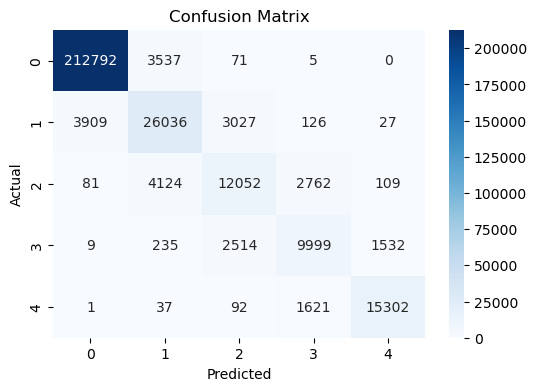


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216405
           1       0.77      0.79      0.78     33125
           2       0.68      0.63      0.65     19128
           3       0.69      0.70      0.69     14289
           4       0.90      0.90      0.90     17053

    accuracy                           0.92    300000
   macro avg       0.80      0.80      0.80    300000
weighted avg       0.92      0.92      0.92    300000



In [19]:
predict_sample_dataset(model=lgbm_model,
                       input_X=X_origin,
                       input_y=y_adjusted,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')

### 6. CatBoostClassifier
- Accuracy       : 0.868
- Precision Score: 0.687
- Recall Score   : 0.671
- F1 Score       : 0.678

In [20]:
cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=100,
    learning_rate=0.1,
    depth=6,
    bootstrap_type='Bernoulli',  # ✅ 改 bootstrap 類型
    subsample=0.1,               # ✅ 讓訓練快 10 倍
    early_stopping_rounds=10,
    random_seed=42,
    verbose=100
)

0:	learn: 1.3719441	test: 1.3716897	best: 1.3716897 (0)	total: 347ms	remaining: 34.4s
99:	learn: 0.3213328	test: 0.3182906	best: 0.3182906 (99)	total: 29.1s	remaining: 0us

bestTest = 0.3182905817
bestIteration = 99

Accuracy       : 0.868
Precision Score: 0.687
Recall Score   : 0.671
F1 Score       : 0.678



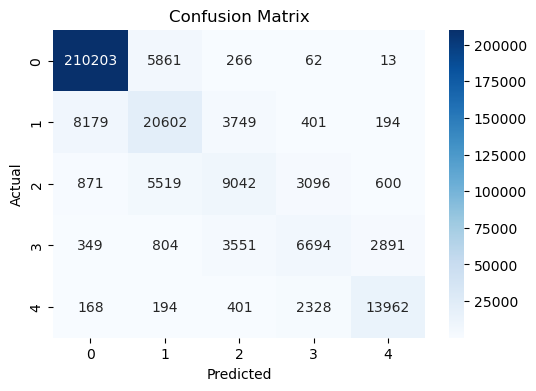


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96    216405
           1       0.62      0.62      0.62     33125
           2       0.53      0.47      0.50     19128
           3       0.53      0.47      0.50     14289
           4       0.79      0.82      0.80     17053

    accuracy                           0.87    300000
   macro avg       0.69      0.67      0.68    300000
weighted avg       0.86      0.87      0.87    300000



In [21]:
predict_sample_dataset(model=cat_model,
                       input_X=X_origin,
                       input_y=y_adjusted,
                       sample_size=1000000,
                       y_type='categorical',
                       is_cat=True)

## Model prediction - Regression
- Use `busyness_zscore_weighted_percentile_4` as target variable
- LightGBMRegressor achieves the best performance among the tested models, but it still performs worse than LightGBM

In [22]:
y_percentile = new_buffer_df['busyness_zscore_weighted_percentile_4']

### 1. LinearRegression
- Accuracy       : 0.435
- Precision Score: 0.473
- Recall Score   : 0.326
- F1 Score       : 0.243


In [23]:
linreg = LinearRegression()

Accuracy       : 0.435
Precision Score: 0.473
Recall Score   : 0.326
F1 Score       : 0.243



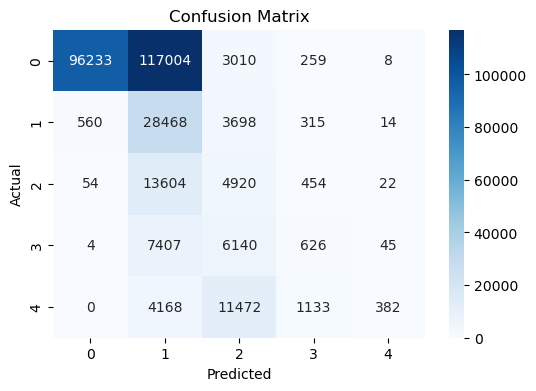


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.44      0.61    216514
           2       0.17      0.86      0.28     33055
           3       0.17      0.26      0.20     19054
           4       0.22      0.04      0.07     14222
           5       0.81      0.02      0.04     17155

    accuracy                           0.44    300000
   macro avg       0.47      0.33      0.24    300000
weighted avg       0.80      0.44      0.49    300000



In [24]:
predict_sample_dataset(model=linreg, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

### 2. Ridge / Lasso Regression
- [Ridge] Performance on simple dataset
    - Accuracy       : 0.435
    - Precision Score: 0.473
    - Recall Score   : 0.326
    - F1 Score       : 0.243
- [Lasso] Performance on simple dataset
    - Accuracy       : 0.712
    - Precision Score: 0.416
    - Recall Score   : 0.241
    - F1 Score       : 0.238

In [25]:
ridge_model = Ridge(alpha=1.0, random_state=42)
lasso_model = Lasso(alpha=0.1, random_state=42)

Accuracy       : 0.435
Precision Score: 0.473
Recall Score   : 0.326
F1 Score       : 0.243



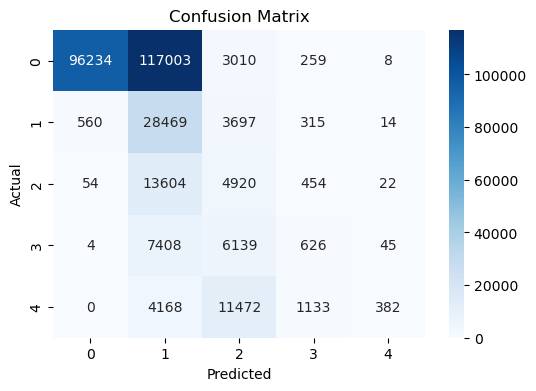


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.44      0.61    216514
           2       0.17      0.86      0.28     33055
           3       0.17      0.26      0.20     19054
           4       0.22      0.04      0.07     14222
           5       0.81      0.02      0.04     17155

    accuracy                           0.44    300000
   macro avg       0.47      0.33      0.24    300000
weighted avg       0.80      0.44      0.49    300000



In [26]:
predict_sample_dataset(model=ridge_model, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

Accuracy       : 0.712
Precision Score: 0.416
Recall Score   : 0.241
F1 Score       : 0.238



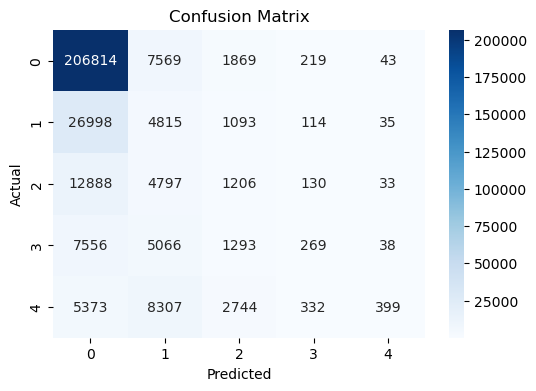


Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.96      0.87    216514
           2       0.16      0.15      0.15     33055
           3       0.15      0.06      0.09     19054
           4       0.25      0.02      0.04     14222
           5       0.73      0.02      0.05     17155

    accuracy                           0.71    300000
   macro avg       0.42      0.24      0.24    300000
weighted avg       0.66      0.71      0.65    300000



In [27]:
predict_sample_dataset(model=lasso_model, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

### 3. SGDRegressor
- Accuracy       : 0.421
- Precision Score: 0.475
- Recall Score   : 0.324
- F1 Score       : 0.239

In [28]:
sgd_regressor = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

Accuracy       : 0.421
Precision Score: 0.475
Recall Score   : 0.324
F1 Score       : 0.239



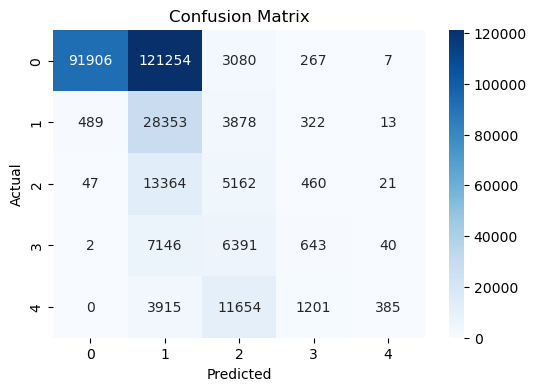


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.42      0.59    216514
           2       0.16      0.86      0.27     33055
           3       0.17      0.27      0.21     19054
           4       0.22      0.05      0.08     14222
           5       0.83      0.02      0.04     17155

    accuracy                           0.42    300000
   macro avg       0.48      0.32      0.24    300000
weighted avg       0.80      0.42      0.48    300000



In [29]:
predict_sample_dataset(model=sgd_regressor, 
                       input_X=X_no_grid_encoded, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

### 4. HistGradientBoostingRegressor
- Accuracy       : 0.81
- Precision Score: 0.645
- Recall Score   : 0.589
- F1 Score       : 0.569

In [30]:
hgb_regressor = HistGradientBoostingRegressor()

Accuracy       : 0.81
Precision Score: 0.645
Recall Score   : 0.589
F1 Score       : 0.569



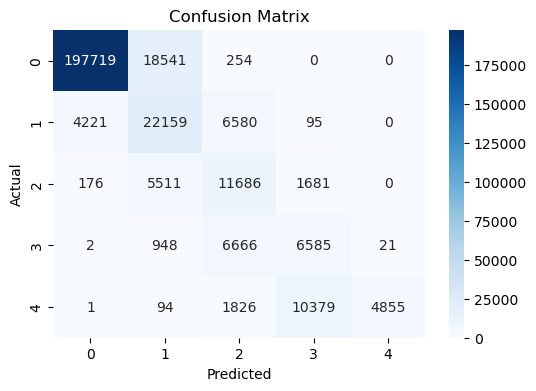


Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.91      0.94    216514
           2       0.47      0.67      0.55     33055
           3       0.43      0.61      0.51     19054
           4       0.35      0.46      0.40     14222
           5       1.00      0.28      0.44     17155

    accuracy                           0.81    300000
   macro avg       0.65      0.59      0.57    300000
weighted avg       0.86      0.81      0.82    300000



In [31]:
predict_sample_dataset(model=hgb_regressor, 
                       input_X=X_no_grid, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous')

### 5. XGBoostRegressor
- Accuracy       : 0.886
- Precision Score: 0.754
- Recall Score   : 0.755
- F1 Score       : 0.74

In [32]:
xgb_regressor = xgb.XGBRegressor(
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

Accuracy       : 0.886
Precision Score: 0.754
Recall Score   : 0.755
F1 Score       : 0.74



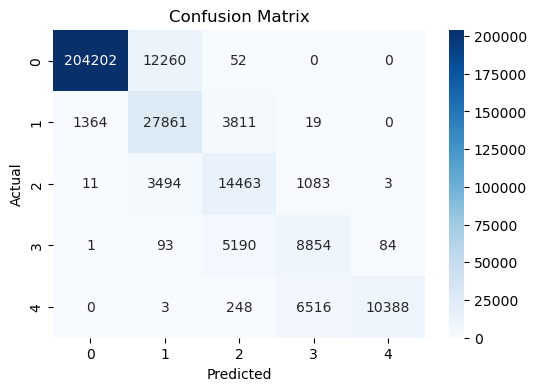


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.94      0.97    216514
           2       0.64      0.84      0.73     33055
           3       0.61      0.76      0.68     19054
           4       0.54      0.62      0.58     14222
           5       0.99      0.61      0.75     17155

    accuracy                           0.89    300000
   macro avg       0.75      0.75      0.74    300000
weighted avg       0.91      0.89      0.89    300000



In [33]:
predict_sample_dataset(model=xgb_regressor, 
                       input_X=X_origin, 
                       input_y=y_percentile, 
                       sample_size=1000000,
                       y_type='continuous'
                      )

### 6. LightGBMRegressor
- Accuracy       : 0.898
- Precision Score: 0.779
- Recall Score   : 0.797
- F1 Score       : 0.778

In [34]:
lgbm_regressor = lgb.LGBMRegressor(
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score 0.476672
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.0254473	valid_0's l2: 0.000647566
Accuracy       : 0.898
Precision Score: 0.779
Recall Score   : 0.797
F1 Score       : 0.778



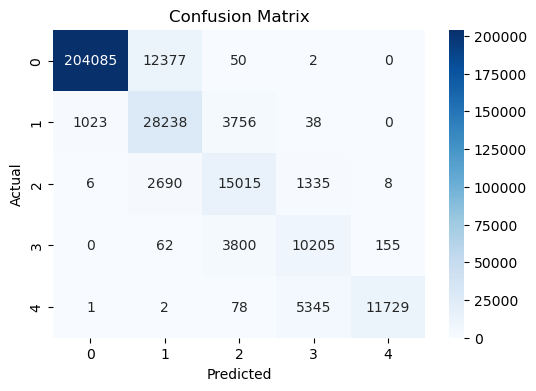


Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.94      0.97    216514
           2       0.65      0.85      0.74     33055
           3       0.66      0.79      0.72     19054
           4       0.60      0.72      0.66     14222
           5       0.99      0.68      0.81     17155

    accuracy                           0.90    300000
   macro avg       0.78      0.80      0.78    300000
weighted avg       0.92      0.90      0.90    300000



In [35]:
predict_sample_dataset(model=lgbm_regressor,
                       input_X=X_origin,
                       input_y=y_percentile,
                       sample_size=1000000,
                       y_type='continuous',
                       is_lgbm=True, 
                       eval_metric='rmse')

### 7. CatBoostRegressor
- Accuracy       : 0.796
- Precision Score: 0.613
- Recall Score   : 0.534
- F1 Score       : 0.512

In [36]:
cat_regressor = CatBoostRegressor(
    loss_function='RMSE',
    iterations=100,
    learning_rate=0.1,
    depth=6,
    early_stopping_rounds=10,
    random_seed=42,
    verbose=100
)

0:	learn: 0.1551128	test: 0.1551815	best: 0.1551815 (0)	total: 95.8ms	remaining: 9.48s
99:	learn: 0.0608472	test: 0.0600071	best: 0.0600071 (99)	total: 10.4s	remaining: 0us

bestTest = 0.06000711309
bestIteration = 99

Accuracy       : 0.796
Precision Score: 0.613
Recall Score   : 0.534
F1 Score       : 0.512



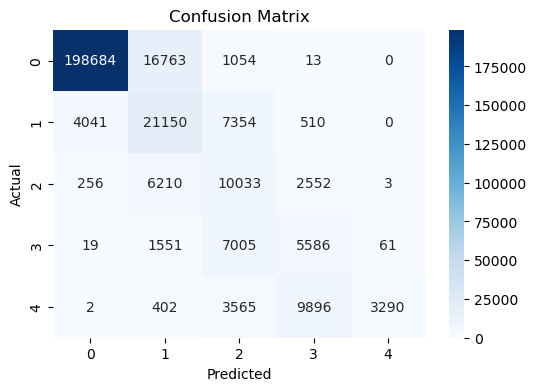


Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.92      0.95    216514
           2       0.46      0.64      0.53     33055
           3       0.35      0.53      0.42     19054
           4       0.30      0.39      0.34     14222
           5       0.98      0.19      0.32     17155

    accuracy                           0.80    300000
   macro avg       0.61      0.53      0.51    300000
weighted avg       0.85      0.80      0.80    300000



In [37]:
predict_sample_dataset(model=cat_regressor,
                       input_X=X_origin,
                       input_y=y_percentile,
                       sample_size=1000000,
                       y_type='continuous',
                       is_cat=True)

# Final Model Development

### Performance on Full Dataset
- busyness_level_4
    - Accuracy       : 0.933
    - Precision Score: 0.836
    - Recall Score   : 0.833
    - F1 Score       : 0.835

===
busyness_level_4
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.163415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.326234
[LightGBM] [Info] Start training from score -2.206549
[LightGBM] [Info] Start training from score -2.752605
[LightGBM] [Info] Start training from score -3.045848
[LightGBM] [Info] Start training from score -2.865292
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0'

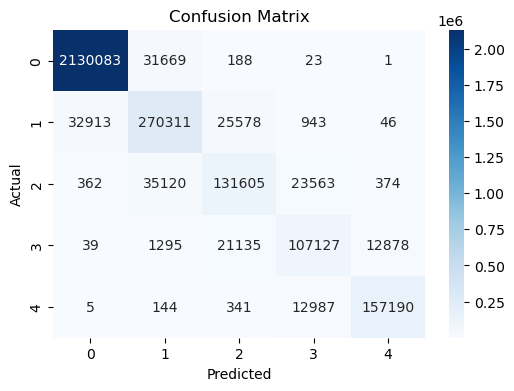


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98   2161964
           1       0.80      0.82      0.81    329791
           2       0.74      0.69      0.71    191024
           3       0.74      0.75      0.75    142474
           4       0.92      0.92      0.92    170667

    accuracy                           0.93   2995920
   macro avg       0.84      0.83      0.83   2995920
weighted avg       0.93      0.93      0.93   2995920



In [20]:
X_lgbm = new_buffer_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                        'grid_id', 'restaurant_count', 'population', # grid info
                        'lat', 'lon', # could be removed
                        'event_count', # event
                       ]]
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

for col in ['busyness_level_4']:
    print("===")
    print(col)
    y_lgbm = new_buffer_df[col]
    y_lgbm = y_lgbm.astype(int) - 1
    
    X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

    lgbm_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=5,
            learning_rate=0.1,
            num_leaves=64,
            n_estimators=100,
            random_state=42
        )
    
    lgbm_model.fit(
        X_train_lgbm, y_train_lgbm,
        eval_set=[(X_test_lgbm, y_test_lgbm)],
        eval_metric='multi_logloss',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(10)]
    )
    
    y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
    classification_evaluation(y_test_lgbm, y_pred_lgbm)

# Refine and Validate Model
- 	Since increasing n_estimators from 100 to 300 has been found to significantly improve model performance while keeping the runtime reasonable in `03_final_score_refinement_and_model_evaluation.ipynb`, this setting will also be applied to this model.
- Additionally, 3-fold Stratified Cross-Validation will be used to evaluate whether the model demonstrates strong and consistent performance across different splits.

## Refine Models
- Accuracy       : 0.949
- Precision Score: 0.874
- Recall Score   : 0.874
- F1 Score       : 0.874

===
busyness_level_4
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.221050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.326234
[LightGBM] [Info] Start training from score -2.206549
[LightGBM] [Info] Start training from score -2.752605
[LightGBM] [Info] Start training from score -3.045848
[LightGBM] [Info] Start training from score -2.865292
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0'

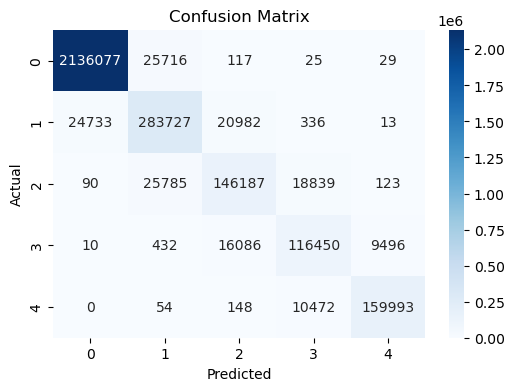


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   2161964
           1       0.85      0.86      0.85    329791
           2       0.80      0.77      0.78    191024
           3       0.80      0.82      0.81    142474
           4       0.94      0.94      0.94    170667

    accuracy                           0.95   2995920
   macro avg       0.87      0.87      0.87   2995920
weighted avg       0.95      0.95      0.95   2995920



In [21]:
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

for col in ['busyness_level_4']:
    print("===")
    print(col)
    y_lgbm = new_buffer_df[col]
    y_lgbm = y_lgbm.astype(int) - 1
    
    X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

    lgbm_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=5,
            learning_rate=0.1,
            num_leaves=64,
            n_estimators=300,
            random_state=42
        )
    
    lgbm_model.fit(
        X_train_lgbm, y_train_lgbm,
        eval_set=[(X_test_lgbm, y_test_lgbm)],
        eval_metric='multi_logloss',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(10)]
    )
    
    y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
    classification_evaluation(y_test_lgbm, y_pred_lgbm)

## Cross-Validation
- Running the full dataset multiple times is time-consuming, so a sample dataset (1M records) was used to test whether the model demonstrates strong and consistent performance.
- The results show that the model delivers stable performance across 3-fold cross-validation, with an average accuracy of approximately 0.927 and a macro F1 score of around 0.818.
- The small gap between training and test scores suggests good generalization with minimal overfitting. These results confirm the robustness of the current hyperparameter settings and model structure.

In [23]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

X_sample = X_lgbm.sample(1000000, random_state=42)
y_sample = y_lgbm.loc[X_sample.index]

kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    lgbm_model,
    X_sample,
    y_sample,
    cv=kf,
    scoring={
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    },
    return_train_score=True,
    n_jobs=-1  # Use all available cores to speed up
)

cv_results_df = pd.DataFrame(cv_results)

In [24]:
cv_results_df

,fit_time,score_time,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro
0,135.9897,117.8679,0.9279,0.9913,0.8207,0.9794,0.8170,0.9781,0.8187,0.9788
1,134.7718,118.6153,0.9282,0.9916,0.8222,0.9808,0.8177,0.9792,0.8198,0.9800
2,134.7778,118.5813,0.9276,0.9918,0.8190,0.9812,0.8159,0.9796,0.8173,0.9803


# Save the model
- Save the model as `lgbm_model_v3.pkl`, duplicate the file to the `data/script/model` directory, and update the model path in the code to ensure it load this version.

In [25]:
import joblib

joblib.dump(lgbm_model, 'lgbm_model_v3.pkl')

['lgbm_model_v3.pkl']

## Test the model
- Ensure the model saved is the correct one

Accuracy       : 0.949
Precision Score: 0.874
Recall Score   : 0.874
F1 Score       : 0.874



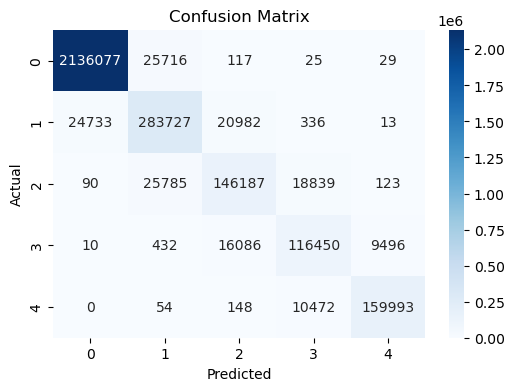


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   2161964
           1       0.85      0.86      0.85    329791
           2       0.80      0.77      0.78    191024
           3       0.80      0.82      0.81    142474
           4       0.94      0.94      0.94    170667

    accuracy                           0.95   2995920
   macro avg       0.87      0.87      0.87   2995920
weighted avg       0.95      0.95      0.95   2995920



In [26]:
model = joblib.load('lgbm_model_v3.pkl')
X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)
y_pred_lgbm = model.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_lgbm)